

# Perceptron et SVM (Support Vector Machine)

## 1) Importation des modules

In [294]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cmx
import pandas as pd
from pandas.io.parsers.readers import read_csv
import seaborn as sns
sns.set_theme(style="whitegrid")

import matplotlib.colors as colors
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits import mplot3d
from sklearn import linear_model, datasets
import seaborn as sns
import itertools
import matplotlib.colors

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.model_selection import ShuffleSplit,  GridSearchCV, cross_validate

from sklearn.tree import plot_tree, DecisionTreeClassifier, DecisionTreeRegressor

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn import tree

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier


from sklearn.linear_model import LogisticRegression
from sklearn import preprocessing

from sklearn.linear_model import Perceptron
from sklearn.neighbors import KNeighborsClassifier


from sklearn import datasets

## 2) Données Iris

Considérons les données iris. On veut prédire l'espèce de l'iris en utilisant ses mesures morphologiques

In [295]:
iris = datasets.load_iris()

Transformons les mesures morphologiques en DataFrame

In [296]:
X = pd.DataFrame(iris.data, columns=['sepal length','sepal width', 'petal length','petal width'])
y = pd.Series(iris.target)
X.head()

,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Utilisons la fonction `sklearn.model_selection.train_test_split` pour diviser les données en un ensemble d'entraînement (100 exemples) et un ensemble de test (le reste des exemples)

In [297]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=80)

Sélection des 2 dimensions sepal width et petal length du domaine des instances et visualisation des données en les colorant en fonction des classes.

<Axes: xlabel='sepal width', ylabel='petal length'>

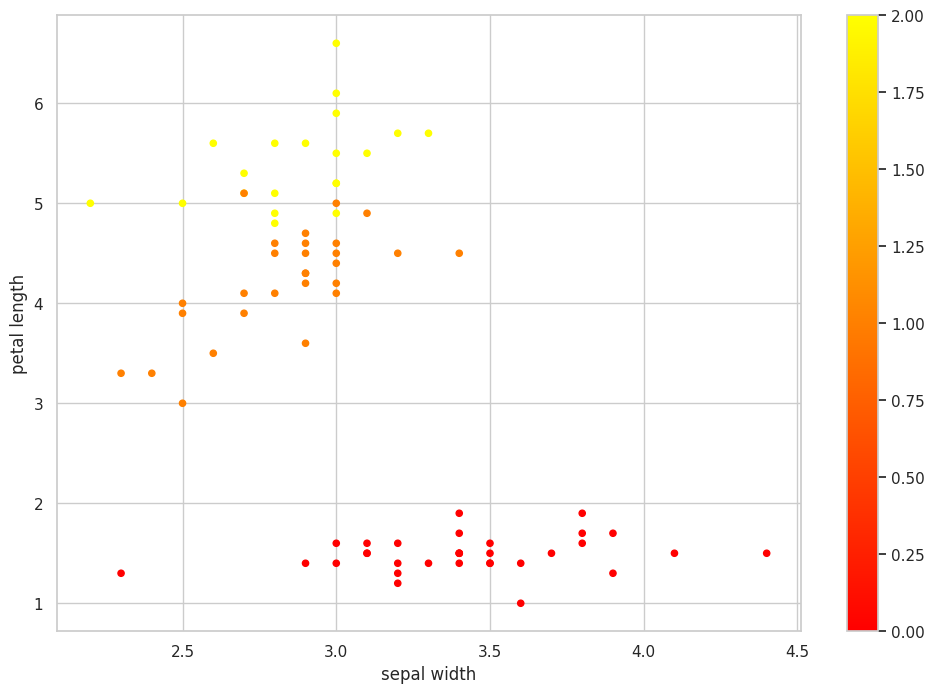

In [298]:
dim = ["sepal width","petal length"]

X_train.plot.scatter(x=dim[0],y=dim[1],c=y_train, colormap="autumn")

Recodons les classes pour avoir un problème de classification binaire avec les iris setosa d'un côté (étiquette -1) et les iris versicolor et virignica de l'autre (étiquette 1). Visualisez les données avec les nouvelles classes.

<Axes: xlabel='sepal width', ylabel='petal length'>

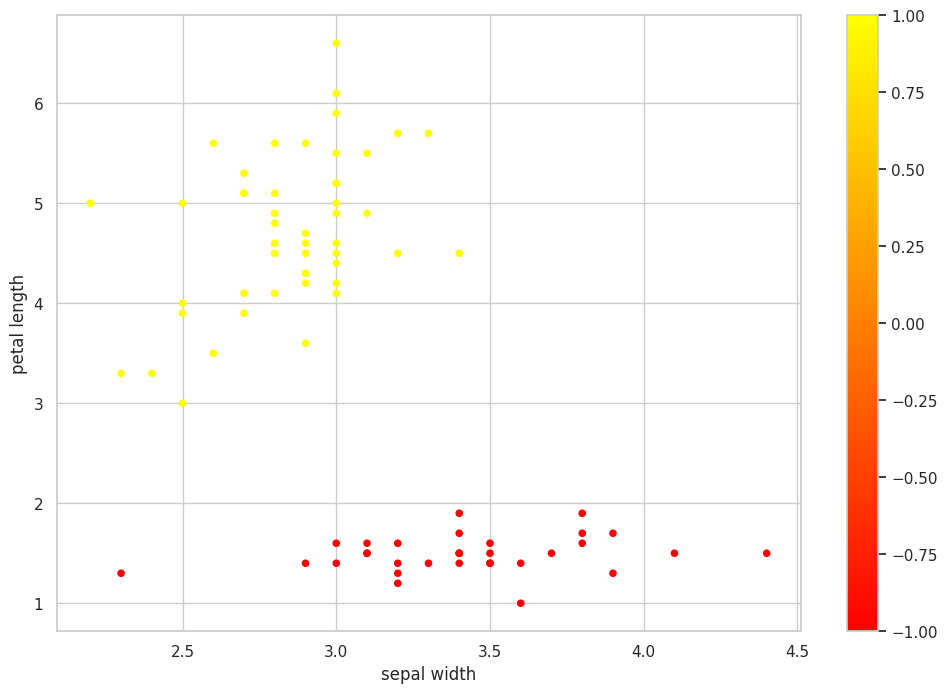

In [299]:
iris.target_names
y_train = y_train.replace([0,1,2],[-1,1,1])
y_test = y_test.replace([0,1,2],[-1,1,1])

X_train.plot.scatter(x=dim[0],y=dim[1],c=y_train, colormap="autumn")

## 3) Classification avec perceptron, SVM, tree, lda, qda, glm (logistic), boosting, bagging (avec tree) et vote avec toutes les méthodes

### Perceptron

Utilisons l'algorithme sklearn.linear_model.Perceptron pour séparer les 2 classes dans le sous-domaine à 2 dimensions sélectionné ci-dessus ou toutes les dimensions. Calculons l'erreur empirique et l'erreur en généralisation. Le résultat est-il surprenant pour les 2 classes ? Pourquoi ?

In [300]:
from sklearn.linear_model import Perceptron
percep_clf = Perceptron()
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=100)
dim = ["sepal width","petal length","petal width","sepal length",]
#dim = ["sepal width","petal length"]
#y_train = y_train.replace([0,1,2],[-1,1,1])
#y_test = y_test.replace([0,1,2],[-1,1,1])
percep_clf.fit(X_train[dim],y_train)


,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


Le modèle appris par le perceptron sépare parfaitement les données. Ce n'est pas surprenant étant donné que nous sommes face à un problème séparable (voir les visualisations précédentes) et que la théorie du Perceptron  garantie que l'approche va trouver un séparateur dans ce cas.

En utilisant le code suivant, nous obtenons des metriques sur la classification

In [301]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


def evaluate(model, X_train, X_test, y_train, y_test):
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    print("RESULTATS TRAINING: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_train, y_train_pred, output_dict=True))
    print(f"MATRICE DE CONFUSION:\n{confusion_matrix(y_train, y_train_pred)}")
    print(f"SCORE ACCURACY:\n{accuracy_score(y_train, y_train_pred):.4f}")
    print(f"RAPPORT CLASSIFICATION:\n{clf_report}")

    print("RESULTS TEST: \n===============================")
    clf_report = pd.DataFrame(classification_report(y_test, y_test_pred, output_dict=True))
    print(f"MATRICE DE CONFUSION:\n{confusion_matrix(y_test, y_test_pred)}")
    print(f"SCORE ACCURACY:\n{accuracy_score(y_test, y_test_pred):.4f}")
    print(f"RAPPORT CLASSIFICATION:\n{clf_report}")


In [302]:
evaluate(percep_clf, X_train[dim], X_test[dim], y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[31  0  0]
 [ 7 28  2]
 [ 0  1 31]]
SCORE ACCURACY:
0.9000
RAPPORT CLASSIFICATION:
                   0          1          2  accuracy   macro avg  weighted avg
precision   0.815789   0.965517   0.939394       0.9    0.906900      0.910742
recall      1.000000   0.756757   0.968750       0.9    0.908502      0.900000
f1-score    0.898551   0.848485   0.953846       0.9    0.900294      0.897721
support    31.000000  37.000000  32.000000       0.9  100.000000    100.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[19  0  0]
 [ 3  8  2]
 [ 0  0 18]]
SCORE ACCURACY:
0.9000
RAPPORT CLASSIFICATION:
                   0          1          2  accuracy  macro avg  weighted avg
precision   0.863636   1.000000   0.900000       0.9   0.921212      0.912182
recall      1.000000   0.615385   1.000000       0.9   0.871795      0.900000
f1-score    0.926829   0.761905   0.947368       0.9   0.878701      0.891343
support    19.000000  13.000000  18.000000   

In [303]:
scores = {
    'Perceptron Classifier': {
        'Train': accuracy_score(y_train, percep_clf.predict(X_train[dim])),
        'Test': accuracy_score(y_test, percep_clf.predict(X_test[dim])),
    },
}

### Bagging (avec tree)

In [304]:
bagging_clf = BaggingClassifier(n_estimators=30, random_state=42)
bagging_clf.fit(X_train[dim], y_train)

evaluate(bagging_clf, X_train[dim], X_test[dim], y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[31  0  0]
 [ 0 37  0]
 [ 0  0 32]]
SCORE ACCURACY:
1.0000
RAPPORT CLASSIFICATION:
              0     1     2  accuracy  macro avg  weighted avg
precision   1.0   1.0   1.0       1.0        1.0           1.0
recall      1.0   1.0   1.0       1.0        1.0           1.0
f1-score    1.0   1.0   1.0       1.0        1.0           1.0
support    31.0  37.0  32.0       1.0      100.0         100.0
RESULTS TEST: 
MATRICE DE CONFUSION:
[[19  0  0]
 [ 0 12  1]
 [ 0  1 17]]
SCORE ACCURACY:
0.9600
RAPPORT CLASSIFICATION:
              0          1          2  accuracy  macro avg  weighted avg
precision   1.0   0.923077   0.944444      0.96    0.95584          0.96
recall      1.0   0.923077   0.944444      0.96    0.95584          0.96
f1-score    1.0   0.923077   0.944444      0.96    0.95584          0.96
support    19.0  13.000000  18.000000      0.96   50.00000         50.00


In [305]:


scores['Bagging Classifier'] = {
        'Train': accuracy_score(y_train, bagging_clf.predict(X_train[dim])),
        'Test': accuracy_score(y_test, bagging_clf.predict(X_test[dim])),
    }

### Boosting

In [306]:
from sklearn.ensemble import AdaBoostClassifier

ada_boost_clf = AdaBoostClassifier(n_estimators=30)
ada_boost_clf.fit(X_train[dim], y_train)
evaluate(ada_boost_clf, X_train[dim], X_test[dim], y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[31  0  0]
 [ 0 36  1]
 [ 0  0 32]]
SCORE ACCURACY:
0.9900
RAPPORT CLASSIFICATION:
              0          1          2  accuracy   macro avg  weighted avg
precision   1.0   1.000000   0.969697      0.99    0.989899      0.990303
recall      1.0   0.972973   1.000000      0.99    0.990991      0.990000
f1-score    1.0   0.986301   0.984615      0.99    0.990306      0.990008
support    31.0  37.000000  32.000000      0.99  100.000000    100.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[19  0  0]
 [ 0 12  1]
 [ 0  1 17]]
SCORE ACCURACY:
0.9600
RAPPORT CLASSIFICATION:
              0          1          2  accuracy  macro avg  weighted avg
precision   1.0   0.923077   0.944444      0.96    0.95584          0.96
recall      1.0   0.923077   0.944444      0.96    0.95584          0.96
f1-score    1.0   0.923077   0.944444      0.96    0.95584          0.96
support    19.0  13.000000  18.000000      0.96   50.00000         50.00


In [307]:
scores['AdaBoost'] = {
        'Train': accuracy_score(y_train, ada_boost_clf.predict(X_train[dim])),
        'Test': accuracy_score(y_test, ada_boost_clf.predict(X_test[dim])),
    }

### LDA

In [308]:

lda_clf = LinearDiscriminantAnalysis()
lda_clf.fit(X_train[dim],y_train)
evaluate(lda_clf, X_train[dim], X_test[dim], y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[31  0  0]
 [ 0 36  1]
 [ 0  1 31]]
SCORE ACCURACY:
0.9800
RAPPORT CLASSIFICATION:
              0          1         2  accuracy   macro avg  weighted avg
precision   1.0   0.972973   0.96875      0.98    0.980574          0.98
recall      1.0   0.972973   0.96875      0.98    0.980574          0.98
f1-score    1.0   0.972973   0.96875      0.98    0.980574          0.98
support    31.0  37.000000  32.00000      0.98  100.000000        100.00
RESULTS TEST: 
MATRICE DE CONFUSION:
[[19  0  0]
 [ 0 12  1]
 [ 0  0 18]]
SCORE ACCURACY:
0.9800
RAPPORT CLASSIFICATION:
              0          1          2  accuracy  macro avg  weighted avg
precision   1.0   1.000000   0.947368      0.98   0.982456      0.981053
recall      1.0   0.923077   1.000000      0.98   0.974359      0.980000
f1-score    1.0   0.960000   0.972973      0.98   0.977658      0.979870
support    19.0  13.000000  18.000000      0.98  50.000000     50.000000


In [309]:
scores['LinearLDA'] = {
        'Train': accuracy_score(y_train, lda_clf.predict(X_train[dim])),
        'Test': accuracy_score(y_test, lda_clf.predict(X_test[dim])),
    }

### QDA

In [310]:
qda_clf = QuadraticDiscriminantAnalysis(store_covariance=True)
qda_clf.fit(X_train[dim],y_train)
evaluate(qda_clf, X_train[dim], X_test[dim], y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[31  0  0]
 [ 0 36  1]
 [ 0  0 32]]
SCORE ACCURACY:
0.9900
RAPPORT CLASSIFICATION:
              0          1          2  accuracy   macro avg  weighted avg
precision   1.0   1.000000   0.969697      0.99    0.989899      0.990303
recall      1.0   0.972973   1.000000      0.99    0.990991      0.990000
f1-score    1.0   0.986301   0.984615      0.99    0.990306      0.990008
support    31.0  37.000000  32.000000      0.99  100.000000    100.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[19  0  0]
 [ 0 12  1]
 [ 0  0 18]]
SCORE ACCURACY:
0.9800
RAPPORT CLASSIFICATION:
              0          1          2  accuracy  macro avg  weighted avg
precision   1.0   1.000000   0.947368      0.98   0.982456      0.981053
recall      1.0   0.923077   1.000000      0.98   0.974359      0.980000
f1-score    1.0   0.960000   0.972973      0.98   0.977658      0.979870
support    19.0  13.000000  18.000000      0.98  50.000000     50.000000


In [311]:
scores['QuadraticLDA'] = {
        'Train': accuracy_score(y_train, qda_clf.predict(X_train[dim])),
        'Test': accuracy_score(y_test, qda_clf.predict(X_test[dim])),
    }

### GLM - Logistique

In [312]:
glm_clf=LogisticRegression()
glm_clf.fit(X_train[dim],y_train)
evaluate(glm_clf, X_train[dim], X_test[dim], y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[31  0  0]
 [ 0 36  1]
 [ 0  1 31]]
SCORE ACCURACY:
0.9800
RAPPORT CLASSIFICATION:
              0          1         2  accuracy   macro avg  weighted avg
precision   1.0   0.972973   0.96875      0.98    0.980574          0.98
recall      1.0   0.972973   0.96875      0.98    0.980574          0.98
f1-score    1.0   0.972973   0.96875      0.98    0.980574          0.98
support    31.0  37.000000  32.00000      0.98  100.000000        100.00
RESULTS TEST: 
MATRICE DE CONFUSION:
[[19  0  0]
 [ 0 12  1]
 [ 0  1 17]]
SCORE ACCURACY:
0.9600
RAPPORT CLASSIFICATION:
              0          1          2  accuracy  macro avg  weighted avg
precision   1.0   0.923077   0.944444      0.96    0.95584          0.96
recall      1.0   0.923077   0.944444      0.96    0.95584          0.96
f1-score    1.0   0.923077   0.944444      0.96    0.95584          0.96
support    19.0  13.000000  18.000000      0.96   50.00000         50.00


In [313]:
scores['GLMlogistic'] = {
        'Train': accuracy_score(y_train, glm_clf.predict(X_train[dim])),
        'Test': accuracy_score(y_test, glm_clf.predict(X_test[dim])),
    }

### Arbre de Decision

In [314]:
tree_clf = DecisionTreeClassifier()
tree_clf.fit(X_train[dim],y_train)
evaluate(tree_clf, X_train[dim], X_test[dim], y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[31  0  0]
 [ 0 37  0]
 [ 0  0 32]]
SCORE ACCURACY:
1.0000
RAPPORT CLASSIFICATION:
              0     1     2  accuracy  macro avg  weighted avg
precision   1.0   1.0   1.0       1.0        1.0           1.0
recall      1.0   1.0   1.0       1.0        1.0           1.0
f1-score    1.0   1.0   1.0       1.0        1.0           1.0
support    31.0  37.0  32.0       1.0      100.0         100.0
RESULTS TEST: 
MATRICE DE CONFUSION:
[[19  0  0]
 [ 0 12  1]
 [ 0  1 17]]
SCORE ACCURACY:
0.9600
RAPPORT CLASSIFICATION:
              0          1          2  accuracy  macro avg  weighted avg
precision   1.0   0.923077   0.944444      0.96    0.95584          0.96
recall      1.0   0.923077   0.944444      0.96    0.95584          0.96
f1-score    1.0   0.923077   0.944444      0.96    0.95584          0.96
support    19.0  13.000000  18.000000      0.96   50.00000         50.00


In [315]:
scores['DecisionTree'] = {
        'Train': accuracy_score(y_train, tree_clf.predict(X_train[dim])),
        'Test': accuracy_score(y_test, tree_clf.predict(X_test[dim])),
    }

### SVM

In [316]:
svm_clf = SVC(gamma='scale')
svm_clf.fit(X_train[dim],y_train)
evaluate(svm_clf, X_train[dim], X_test[dim], y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[31  0  0]
 [ 0 36  1]
 [ 0  3 29]]
SCORE ACCURACY:
0.9600
RAPPORT CLASSIFICATION:
              0          1          2  accuracy   macro avg  weighted avg
precision   1.0   0.923077   0.966667      0.96    0.963248      0.960872
recall      1.0   0.972973   0.906250      0.96    0.959741      0.960000
f1-score    1.0   0.947368   0.935484      0.96    0.960951      0.959881
support    31.0  37.000000  32.000000      0.96  100.000000    100.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[19  0  0]
 [ 0 12  1]
 [ 0  1 17]]
SCORE ACCURACY:
0.9600
RAPPORT CLASSIFICATION:
              0          1          2  accuracy  macro avg  weighted avg
precision   1.0   0.923077   0.944444      0.96    0.95584          0.96
recall      1.0   0.923077   0.944444      0.96    0.95584          0.96
f1-score    1.0   0.923077   0.944444      0.96    0.95584          0.96
support    19.0  13.000000  18.000000      0.96   50.00000         50.00


In [317]:
scores['SVM'] = {
        'Train': accuracy_score(y_train, svm_clf.predict(X_train[dim])),
        'Test': accuracy_score(y_test, svm_clf.predict(X_test[dim])),
    }

### Vote

In [318]:
estimators = []
percep_reg = Perceptron()
estimators.append(('Perceptron', percep_reg))

log_reg = LogisticRegression(solver='liblinear')
estimators.append(('Logistic', log_reg))

tree = DecisionTreeClassifier()
estimators.append(('Tree', tree))

svm_clf = SVC(gamma='scale')
estimators.append(('SVM', svm_clf))

lda_clf = LinearDiscriminantAnalysis()
estimators.append(('LDA', lda_clf))

qda_clf = QuadraticDiscriminantAnalysis(store_covariance=True)
estimators.append(('QDA', qda_clf))

ada_boost_clf = AdaBoostClassifier(n_estimators=30)
estimators.append(('Boosting', ada_boost_clf))


bagging_clf = BaggingClassifier(n_estimators=30, random_state=42)
estimators.append(('Bagging', bagging_clf))


voting = VotingClassifier(estimators=estimators)
voting.fit(X_train[dim], y_train)

evaluate(voting, X_train[dim], X_test[dim], y_train, y_test)

ValueError: The 'liblinear' solver does not support multiclass classification (n_classes >= 3). Either use another solver or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.

In [ ]:
scores['Voting'] = {
        'Train': accuracy_score(y_train, voting.predict(X_train[dim])),
        'Test': accuracy_score(y_test, voting.predict(X_test[dim])),
    }

AttributeError: 'VotingClassifier' object has no attribute 'estimators_'

### Comparaison des méthodes avec un seul échantillon


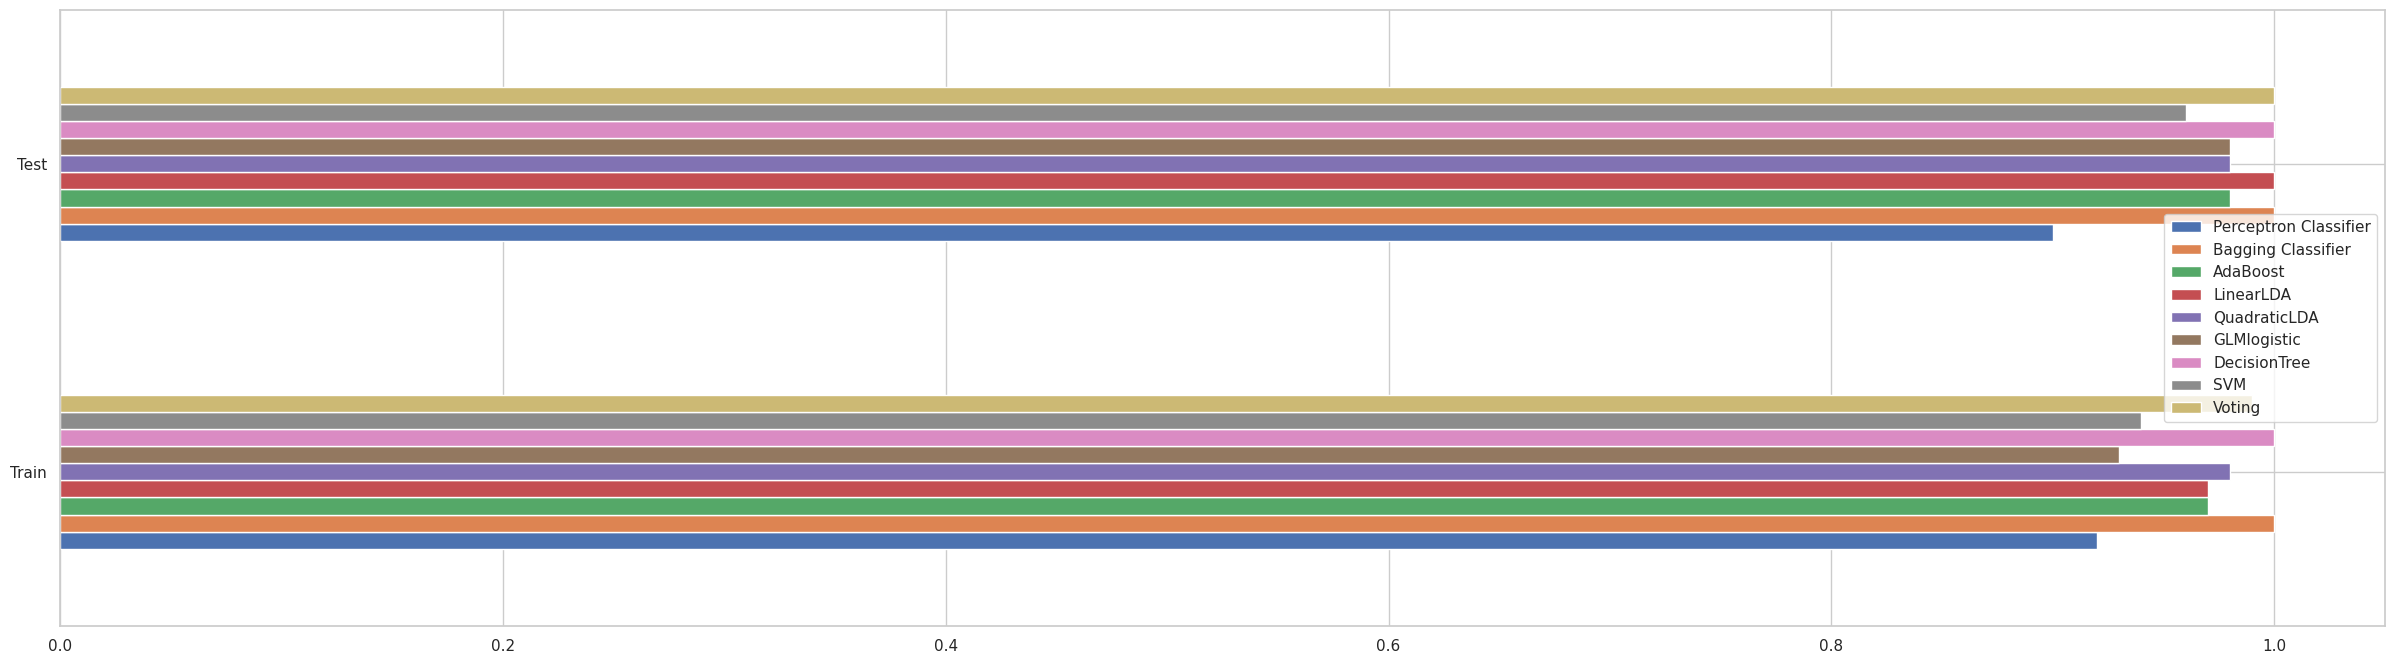

In [ ]:
scores_df = pd.DataFrame(scores)

scores_df.plot(kind='barh', figsize=(30, 8))

plt.savefig("comparaison_iris.pdf", format="pdf", bbox_inches="tight")
plt.show()



### Replications avec LDA

LDA : Mean (std) Error :  0.0247 ( 0.03 )
Actual             0         1         2
Predicted                               
0          10.446667  0.000000  0.000000
1           0.000000  9.193333  0.286667
2           0.000000  0.466667  9.606667


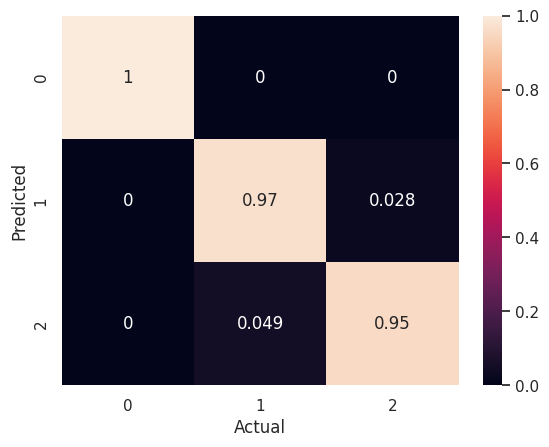

In [ ]:
import seaborn as sn
B = 150
err_bg = np.zeros(B)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2)
lda_clf = LinearDiscriminantAnalysis()

lda_clf.fit(X_train, y_train)
y_pred = lda_clf.predict(X_test)
err_bg[1] = 1-np.mean(y_pred==y_test)
cm_concat=pd.crosstab(y_pred, y_test, rownames=['Predicted'], colnames=['Actual'], margins=False)

for b in range((B-1)):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2)
    lda_clf = LinearDiscriminantAnalysis()
    lda_clf.fit(X_train, y_train)

    y_pred = lda_clf.predict(X_test)
    cm=pd.crosstab(y_pred, y_test, rownames=['Predicted'], colnames=['Actual'], margins=False)
    err_bg[b] = 1-np.mean(y_pred==y_test)
    cm_concat = pd.concat((cm_concat, cm))






print("LDA : Mean (std) Error : ",np.round(np.mean(err_bg),4),
      "(",np.round(np.std(err_bg),2),")")
cm_group = cm_concat.groupby(cm_concat.index)
cm_group.mean()


cm_groupf=cm_group.mean()
print(cm_groupf)

cm_normalized = cm_groupf/cm_groupf.sum(axis=1)
sn.heatmap(cm_normalized, annot=True)

plt.savefig("Confusion-matrice.pdf", bbox_inches='tight')


### Classification et ACP

In [ ]:
# ACP avec toutes les données

from sklearn.preprocessing import StandardScaler

xall_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

Xall_pca = pca.fit_transform(xall_scaled)

In [ ]:
### acp avec le training
x_scaled = StandardScaler().fit_transform(X_train)


X_pca = pca.fit_transform(x_scaled)


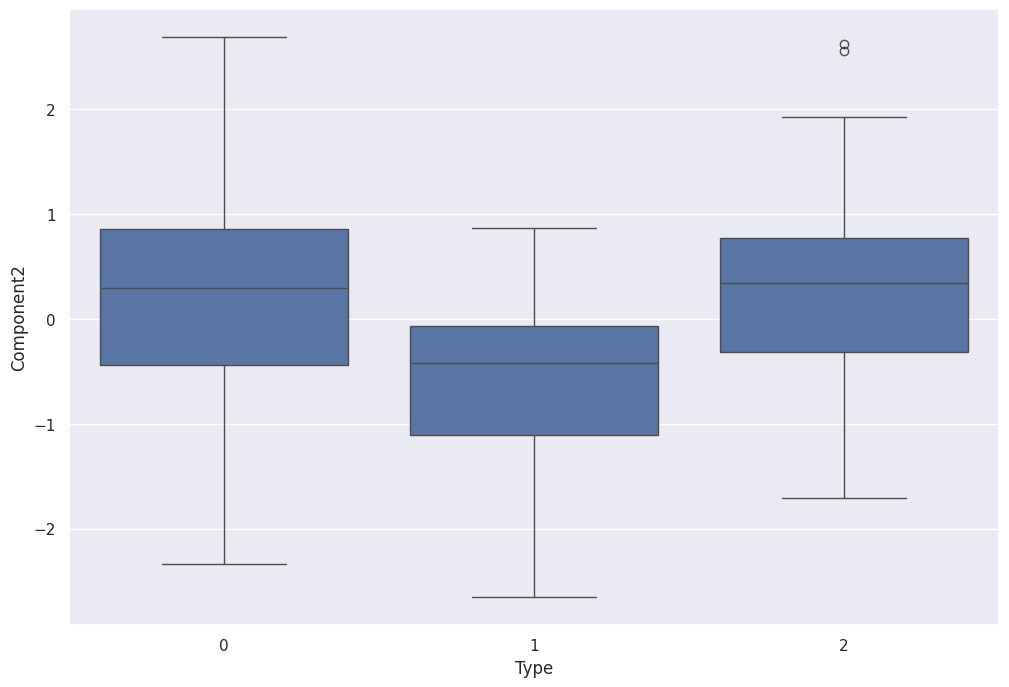

In [ ]:
import seaborn as sns

dfall=pd.DataFrame(zip(Xall_pca[:,0],Xall_pca[:,1],y),columns=["Component1","Component2","Type"])
sns.set(rc={'figure.figsize':(12,8)})

#sns.boxplot(x='Type', y='Component1', data=dfall)
sns.boxplot(x='Type', y='Component2', data=dfall)
#saver le boxplot
#plt.savefig("boxplotpca1.pdf", format="pdf", bbox_inches="tight")
plt.show()

#saver les composantes
dfall.to_csv('pcacomponents.csv', index=True)


In [ ]:

dftrain=pd.DataFrame(zip(X_pca[:,0],X_pca[:,1],y_train),columns=["Component1","Component2","Type"])
dftrain.head()

,Component1,Component2,Type
0,1.833862,0.311922,2
1,0.004558,-1.043880,1
2,0.412183,-1.748395,1
3,0.227650,-0.778919,1
4,-2.512215,2.082088,0


### LDA

In [ ]:
def visualize(clf,X1,X2,y):
    """ Permet de visualiser la frontière de décision du classificateur clf.

    Parameters
    ----------
    clf :
        Le classificateur à visualiser
    X1 :
        La première dimension des données
    X2 :
        La seconde dimension des données
    y :
        Les étiquettes des exemples

    """
    # Plotting decision regions
    x_min, x_max = np.array(X1).min() - 1, np.array(X1).max() + 1
    y_min, y_max = np.array(X2).min() - 1, np.array(X2).max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X1, X2, c=y, s=20, edgecolor='k')

    plt.show()


df1train = dftrain[["Component1", "Component2"]]

lda_clf = LinearDiscriminantAnalysis()

lda_clf.fit(df1train,y_train)
dim2 = ['Component1','Component2', "Type"]
visualize(lda_clf,df1train[dim2[0]],df1train[dim2[1]],y_train)


ValueError: Found input variables with inconsistent numbers of samples: [120, 100]

In [ ]:

df1all = dfall[["Component1", "Component2"]]

In [ ]:
xtest_scaled = StandardScaler().fit_transform(X_test)

pca = PCA(n_components=2)
Xtest_pca = pca.fit_transform(xtest_scaled)
df1test=pd.DataFrame(zip(Xtest_pca[:,0],Xtest_pca[:,1]),columns=["Component1","Component2"])

In [ ]:
evaluate(lda_clf, df1train, df1test, y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[39  0  0]
 [ 0 36  4]
 [ 0  5 36]]
SCORE ACCURACY:
0.9250
RAPPORT CLASSIFICATION:
              0          1          2  accuracy   macro avg  weighted avg
precision   1.0   0.878049   0.900000     0.925    0.926016      0.925183
recall      1.0   0.900000   0.878049     0.925    0.926016      0.925000
f1-score    1.0   0.888889   0.888889     0.925    0.925926      0.925000
support    39.0  40.000000  41.000000     0.925  120.000000    120.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[11  0  0]
 [ 0  8  2]
 [ 0  0  9]]
SCORE ACCURACY:
0.9333
RAPPORT CLASSIFICATION:
              0          1         2  accuracy  macro avg  weighted avg
precision   1.0   1.000000  0.818182  0.933333   0.939394      0.945455
recall      1.0   0.800000  1.000000  0.933333   0.933333      0.933333
f1-score    1.0   0.888889  0.900000  0.933333   0.929630      0.932963
support    11.0  10.000000  9.000000  0.933333  30.000000     30.000000


In [ ]:
scorespca = {
    'LinearLDA': {
        'Train': accuracy_score(y_train, lda_clf.predict(df1train)),
        'Test': accuracy_score(y_test, lda_clf.predict(df1test)),
    },
}


NotFittedError: This LinearDiscriminantAnalysis instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

### Perceptron

/home/layedev/Documents/miashs2026/MQME2026_SEMESTRE2/data mining/supervisé/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


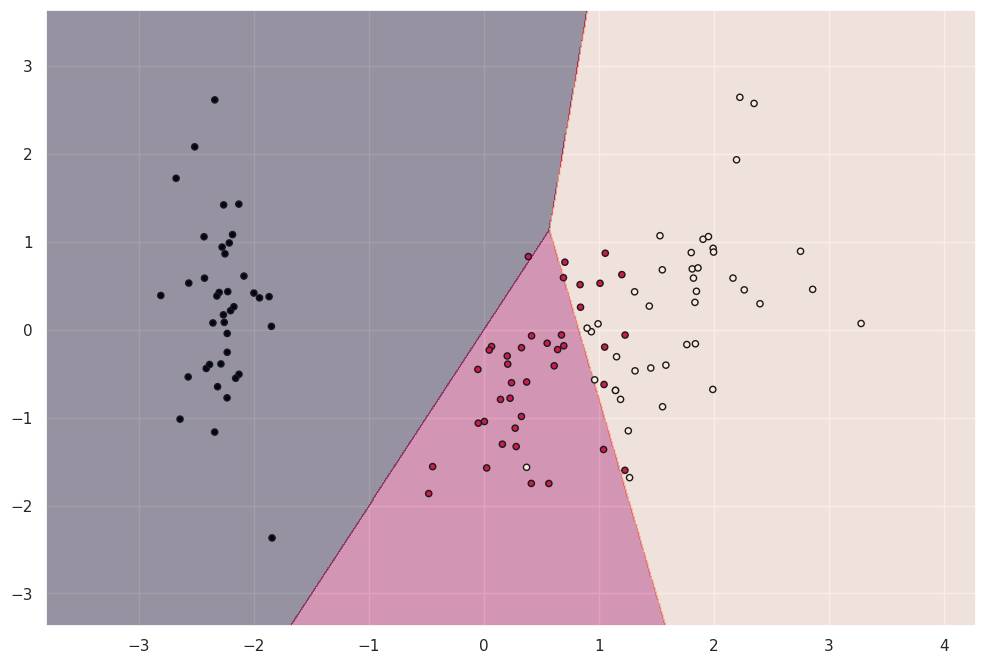

In [ ]:
percep_clf = Perceptron()
percep_clf.fit(df1train, y_train)
visualize(percep_clf,df1train[dim2[0]],df1train[dim2[1]],y_train)

In [ ]:
evaluate(percep_clf, df1train, df1test, y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[39  0  0]
 [ 1 29 10]
 [ 0  1 40]]
SCORE ACCURACY:
0.9000
RAPPORT CLASSIFICATION:
                   0          1          2  accuracy   macro avg  weighted avg
precision   0.975000   0.966667   0.800000       0.9    0.913889      0.912431
recall      1.000000   0.725000   0.975610       0.9    0.900203      0.900000
f1-score    0.987342   0.828571   0.879121       0.9    0.898345      0.897443
support    39.000000  40.000000  41.000000       0.9  120.000000    120.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[11  0  0]
 [ 0  6  4]
 [ 0  0  9]]
SCORE ACCURACY:
0.8667
RAPPORT CLASSIFICATION:
              0      1         2  accuracy  macro avg  weighted avg
precision   1.0   1.00  0.692308  0.866667   0.897436      0.907692
recall      1.0   0.60  1.000000  0.866667   0.866667      0.866667
f1-score    1.0   0.75  0.818182  0.866667   0.856061      0.862121
support    11.0  10.00  9.000000  0.866667  30.000000     30.000000


In [ ]:
scorespca['Perceptron'] = {
        'Train': accuracy_score(y_train, percep_clf.predict(df1train)),
        'Test': accuracy_score(y_test, percep_clf.predict(df1test)),
    }

### Tree

/home/layedev/Documents/miashs2026/MQME2026_SEMESTRE2/data mining/supervisé/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but BaggingClassifier was fitted with feature names
  warnings.warn(


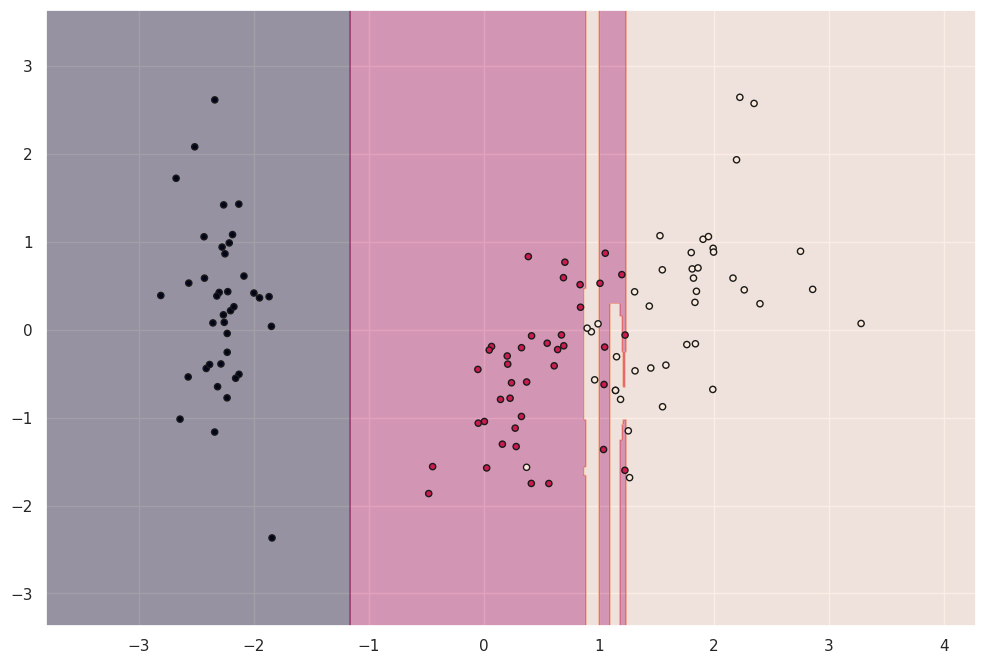

In [ ]:

bagging_clf = BaggingClassifier(n_estimators=30, random_state=42)
bagging_clf.fit(df1train, y_train)

visualize(bagging_clf,df1train[dim2[0]],df1train[dim2[1]],y_train)

In [ ]:

evaluate(bagging_clf, df1train, df1test, y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[39  0  0]
 [ 0 40  0]
 [ 0  0 41]]
SCORE ACCURACY:
1.0000
RAPPORT CLASSIFICATION:
              0     1     2  accuracy  macro avg  weighted avg
precision   1.0   1.0   1.0       1.0        1.0           1.0
recall      1.0   1.0   1.0       1.0        1.0           1.0
f1-score    1.0   1.0   1.0       1.0        1.0           1.0
support    39.0  40.0  41.0       1.0      120.0         120.0
RESULTS TEST: 
MATRICE DE CONFUSION:
[[11  0  0]
 [ 0  7  3]
 [ 0  1  8]]
SCORE ACCURACY:
0.8667
RAPPORT CLASSIFICATION:
              0          1         2  accuracy  macro avg  weighted avg
precision   1.0   0.875000  0.727273  0.866667   0.867424      0.876515
recall      1.0   0.700000  0.888889  0.866667   0.862963      0.866667
f1-score    1.0   0.777778  0.800000  0.866667   0.859259      0.865926
support    11.0  10.000000  9.000000  0.866667  30.000000     30.000000


In [ ]:
scorespca['Bagging Classifier'] = {
        'Train': accuracy_score(y_train, bagging_clf.predict(df1train)),
        'Test': accuracy_score(y_test, bagging_clf.predict(df1test)),
    }

/home/layedev/Documents/miashs2026/MQME2026_SEMESTRE2/data mining/supervisé/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


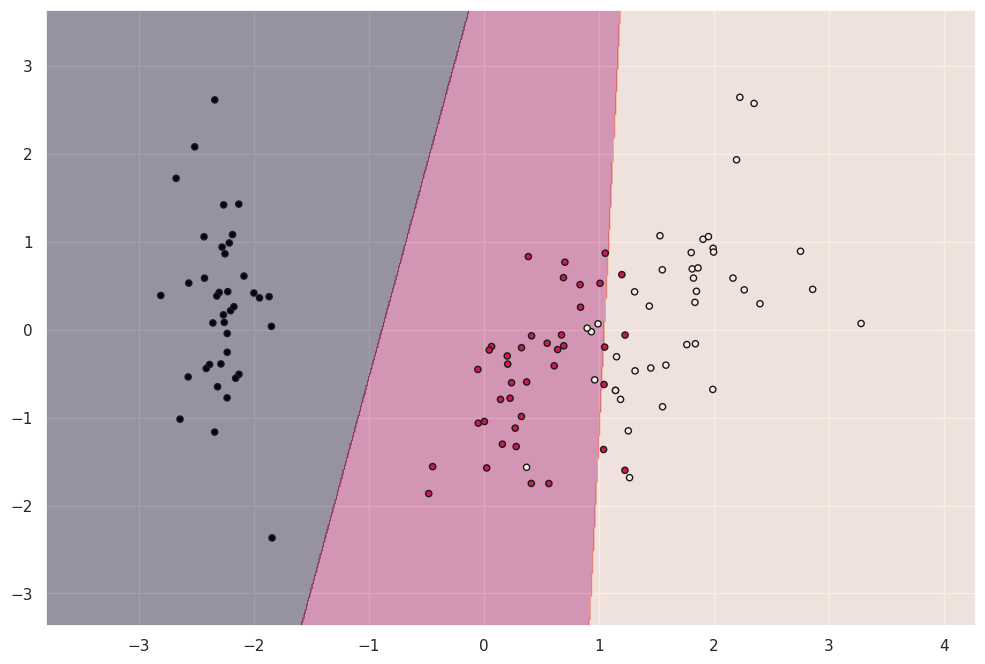

In [ ]:
glm_clf=LogisticRegression()
glm_clf.fit(df1train,y_train)

visualize(glm_clf,df1train[dim2[0]],df1train[dim2[1]],y_train)

In [ ]:
evaluate(glm_clf, df1train, df1test, y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[39  0  0]
 [ 0 34  6]
 [ 0  5 36]]
SCORE ACCURACY:
0.9083
RAPPORT CLASSIFICATION:
              0          1          2  accuracy   macro avg  weighted avg
precision   1.0   0.871795   0.857143  0.908333    0.909646      0.908455
recall      1.0   0.850000   0.878049  0.908333    0.909350      0.908333
f1-score    1.0   0.860759   0.867470  0.908333    0.909410      0.908305
support    39.0  40.000000  41.000000  0.908333  120.000000    120.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[11  0  0]
 [ 0  7  3]
 [ 0  0  9]]
SCORE ACCURACY:
0.9000
RAPPORT CLASSIFICATION:
              0          1         2  accuracy  macro avg  weighted avg
precision   1.0   1.000000  0.750000       0.9   0.916667      0.925000
recall      1.0   0.700000  1.000000       0.9   0.900000      0.900000
f1-score    1.0   0.823529  0.857143       0.9   0.893557      0.898319
support    11.0  10.000000  9.000000       0.9  30.000000     30.000000


In [ ]:
scorespca['GLMlogistic'] = {
        'Train': accuracy_score(y_train, glm_clf.predict(df1train)),
        'Test': accuracy_score(y_test, glm_clf.predict(df1test)),
    }

/home/layedev/Documents/miashs2026/MQME2026_SEMESTRE2/data mining/supervisé/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


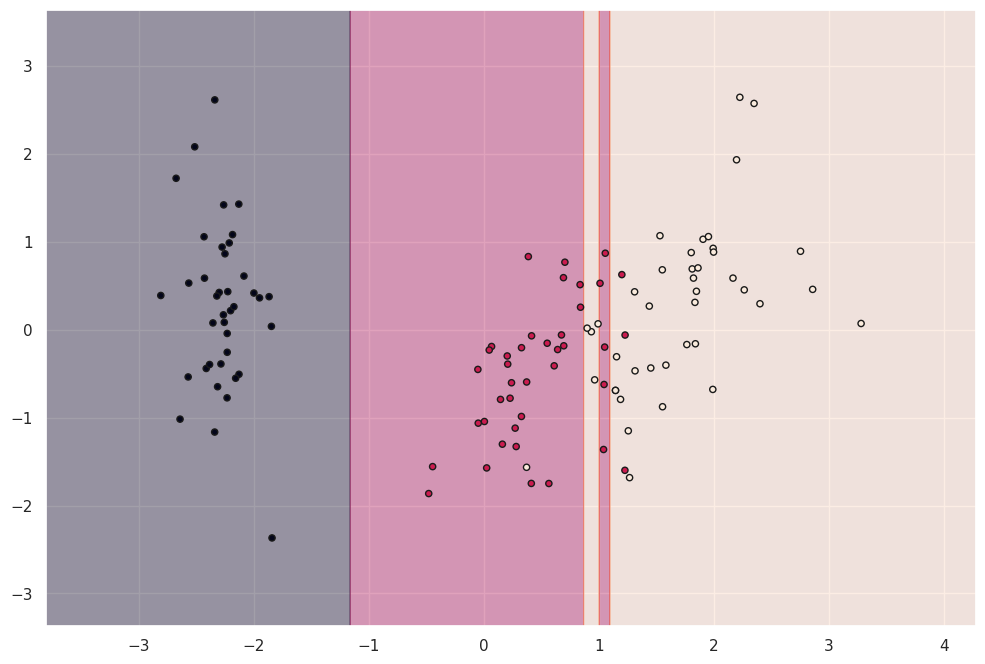

In [ ]:
ada_boost_clf = AdaBoostClassifier(n_estimators=30)
ada_boost_clf.fit(df1train, y_train)
visualize(ada_boost_clf,df1train[dim2[0]],df1train[dim2[1]],y_train)

In [ ]:
evaluate(ada_boost_clf, df1train, df1test, y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[39  0  0]
 [ 0 40  3]
 [ 0  0 38]]
SCORE ACCURACY:
0.9750
RAPPORT CLASSIFICATION:
              0          1          2  accuracy   macro avg  weighted avg
precision   1.0   1.000000   0.926829     0.975    0.975610      0.976829
recall      1.0   0.930233   1.000000     0.975    0.976744      0.975000
f1-score    1.0   0.963855   0.962025     0.975    0.975294      0.975023
support    39.0  43.000000  38.000000     0.975  120.000000    120.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[11  0  0]
 [ 0  7  0]
 [ 0  2 10]]
SCORE ACCURACY:
0.9333
RAPPORT CLASSIFICATION:
              0         1          2  accuracy  macro avg  weighted avg
precision   1.0  0.777778   1.000000  0.933333   0.925926      0.948148
recall      1.0  1.000000   0.833333  0.933333   0.944444      0.933333
f1-score    1.0  0.875000   0.909091  0.933333   0.928030      0.934470
support    11.0  7.000000  12.000000  0.933333  30.000000     30.000000


In [ ]:
scorespca['AdaBoost'] = {
        'Train': accuracy_score(y_train, ada_boost_clf.predict(df1train)),
        'Test': accuracy_score(y_test, ada_boost_clf.predict(df1test)),
    }

/home/layedev/Documents/miashs2026/MQME2026_SEMESTRE2/data mining/supervisé/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


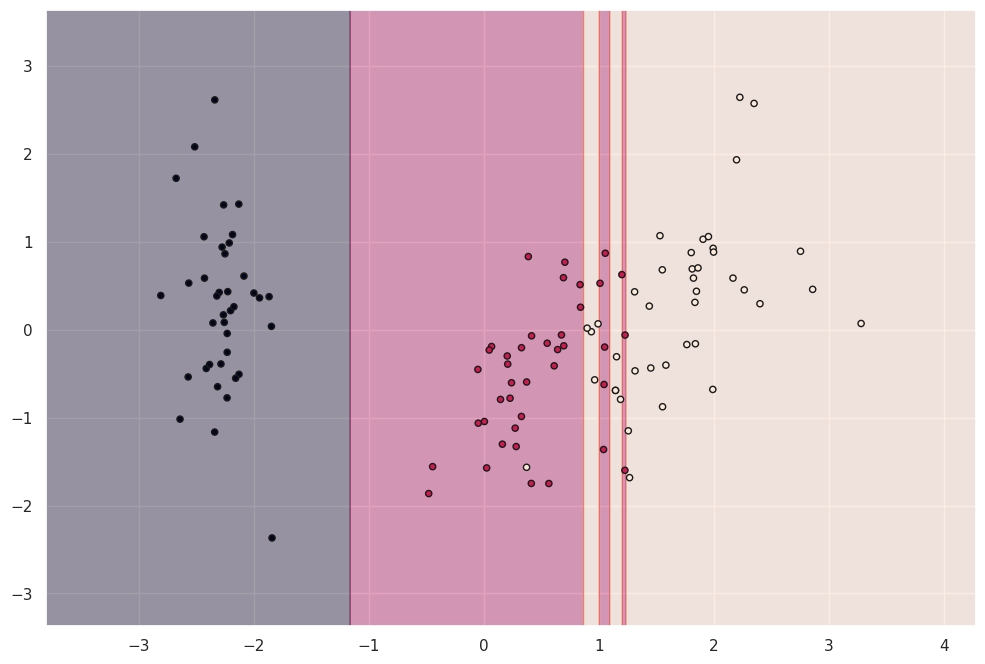

In [ ]:
tree_clf = DecisionTreeClassifier()
tree_clf.fit(df1train,y_train)
visualize(tree_clf,df1train[dim2[0]],df1train[dim2[1]],y_train)

In [ ]:
evaluate(tree_clf, df1train, df1test, y_train, y_test)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Component1
- Component2
Feature names seen at fit time, yet now missing:
- petal length
- petal width
- sepal length
- sepal width


In [ ]:
scorespca['DecisionTree'] = {
        'Train': accuracy_score(y_train, tree_clf.predict(df1train)),
        'Test': accuracy_score(y_test, tree_clf.predict(df1test)),
    }

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Component1
- Component2
Feature names seen at fit time, yet now missing:
- petal length
- petal width
- sepal length
- sepal width


In [ ]:
voting = VotingClassifier(estimators=estimators)
voting.fit(df1train, y_train)
visualize(voting,df1train[dim2[0]],df1train[dim2[1]],y_train)

ValueError: Found input variables with inconsistent numbers of samples: [120, 100]

In [ ]:
evaluate(voting, df1train, df1test, y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[39  0  0]
 [ 0 39  4]
 [ 0  1 37]]
SCORE ACCURACY:
0.9583
RAPPORT CLASSIFICATION:
              0          1          2  accuracy   macro avg  weighted avg
precision   1.0   0.975000   0.902439  0.958333    0.959146      0.960147
recall      1.0   0.906977   0.973684  0.958333    0.960220      0.958333
f1-score    1.0   0.939759   0.936709  0.958333    0.958823      0.958371
support    39.0  43.000000  38.000000  0.958333  120.000000    120.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[11  0  0]
 [ 0  7  0]
 [ 0  2 10]]
SCORE ACCURACY:
0.9333
RAPPORT CLASSIFICATION:
              0         1          2  accuracy  macro avg  weighted avg
precision   1.0  0.777778   1.000000  0.933333   0.925926      0.948148
recall      1.0  1.000000   0.833333  0.933333   0.944444      0.933333
f1-score    1.0  0.875000   0.909091  0.933333   0.928030      0.934470
support    11.0  7.000000  12.000000  0.933333  30.000000     30.000000


In [ ]:
scorespca['Voting'] = {
        'Train': accuracy_score(y_train, voting.predict(df1train)),
        'Test': accuracy_score(y_test, voting.predict(df1test)),
    }

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but QuadraticDiscriminantAnalysis was fitted with feature names
  warnings.warn(


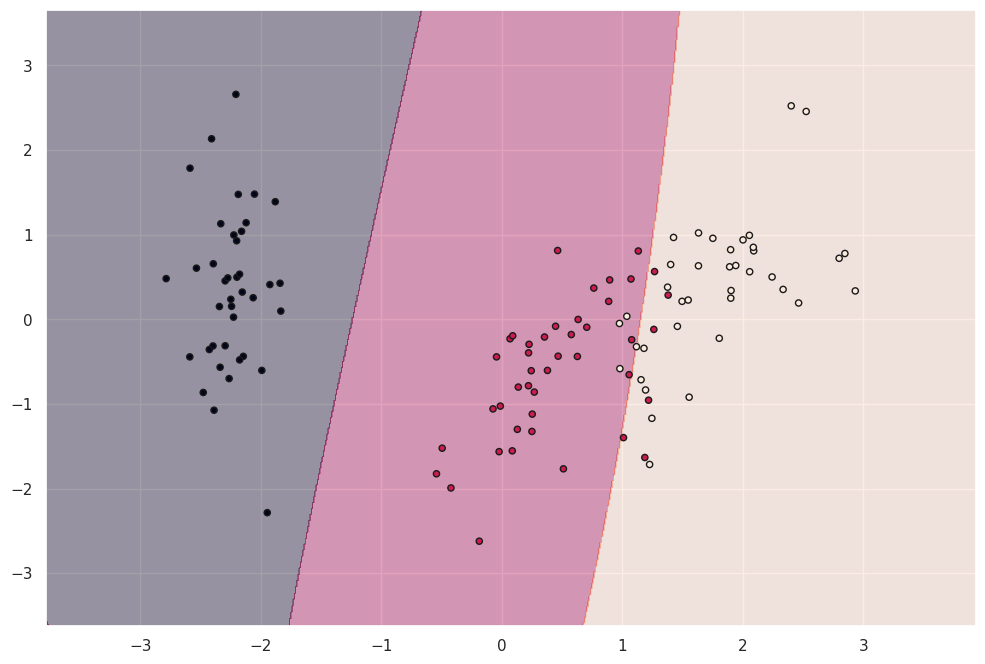

In [ ]:
qda_clf = QuadraticDiscriminantAnalysis(store_covariance=True)
qda_clf.fit(df1train,y_train)
visualize(qda_clf,df1train[dim2[0]],df1train[dim2[1]],y_train)

In [ ]:
evaluate(qda_clf, df1train, df1test, y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[39  0  0]
 [ 0 37  6]
 [ 0  4 34]]
SCORE ACCURACY:
0.9167
RAPPORT CLASSIFICATION:
              0          1          2  accuracy   macro avg  weighted avg
precision   1.0   0.902439   0.850000  0.916667    0.917480      0.917541
recall      1.0   0.860465   0.894737  0.916667    0.918401      0.916667
f1-score    1.0   0.880952   0.871795  0.916667    0.917582      0.916743
support    39.0  43.000000  38.000000  0.916667  120.000000    120.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[11  0  0]
 [ 0  7  0]
 [ 0  2 10]]
SCORE ACCURACY:
0.9333
RAPPORT CLASSIFICATION:
              0         1          2  accuracy  macro avg  weighted avg
precision   1.0  0.777778   1.000000  0.933333   0.925926      0.948148
recall      1.0  1.000000   0.833333  0.933333   0.944444      0.933333
f1-score    1.0  0.875000   0.909091  0.933333   0.928030      0.934470
support    11.0  7.000000  12.000000  0.933333  30.000000     30.000000


In [ ]:
scorespca['QuadraticLDA'] = {
        'Train': accuracy_score(y_train, qda_clf.predict(df1train)),
        'Test': accuracy_score(y_test, qda_clf.predict(df1test)),
    }

### SVM

/home/layedev/Documents/miashs2026/MQME2026_SEMESTRE2/data mining/supervisé/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


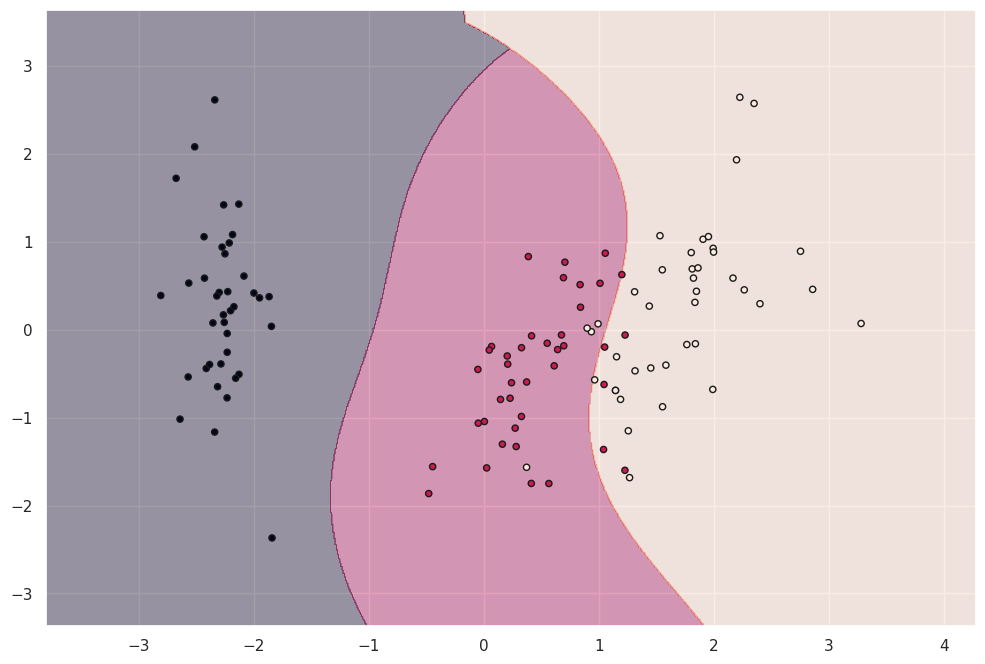

In [ ]:

svm_clf = SVC(gamma='scale')
svm_clf.fit(df1train,y_train)
visualize(svm_clf,df1train[dim2[0]],df1train[dim2[1]],y_train)

In [ ]:
evaluate(svm_clf, df1train, df1test, y_train, y_test)

RESULTATS TRAINING: 
MATRICE DE CONFUSION:
[[39  0  0]
 [ 0 34  6]
 [ 0  4 37]]
SCORE ACCURACY:
0.9167
RAPPORT CLASSIFICATION:
              0          1          2  accuracy   macro avg  weighted avg
precision   1.0   0.894737   0.860465  0.916667    0.918401      0.917238
recall      1.0   0.850000   0.902439  0.916667    0.917480      0.916667
f1-score    1.0   0.871795   0.880952  0.916667    0.917582      0.916590
support    39.0  40.000000  41.000000  0.916667  120.000000    120.000000
RESULTS TEST: 
MATRICE DE CONFUSION:
[[11  0  0]
 [ 0  8  2]
 [ 0  0  9]]
SCORE ACCURACY:
0.9333
RAPPORT CLASSIFICATION:
              0          1         2  accuracy  macro avg  weighted avg
precision   1.0   1.000000  0.818182  0.933333   0.939394      0.945455
recall      1.0   0.800000  1.000000  0.933333   0.933333      0.933333
f1-score    1.0   0.888889  0.900000  0.933333   0.929630      0.932963
support    11.0  10.000000  9.000000  0.933333  30.000000     30.000000


In [ ]:
scorespca['SVM'] = {
        'Train': accuracy_score(y_train, svm_clf.predict(df1train)),
        'Test': accuracy_score(y_test, svm_clf.predict(df1test)),
    }

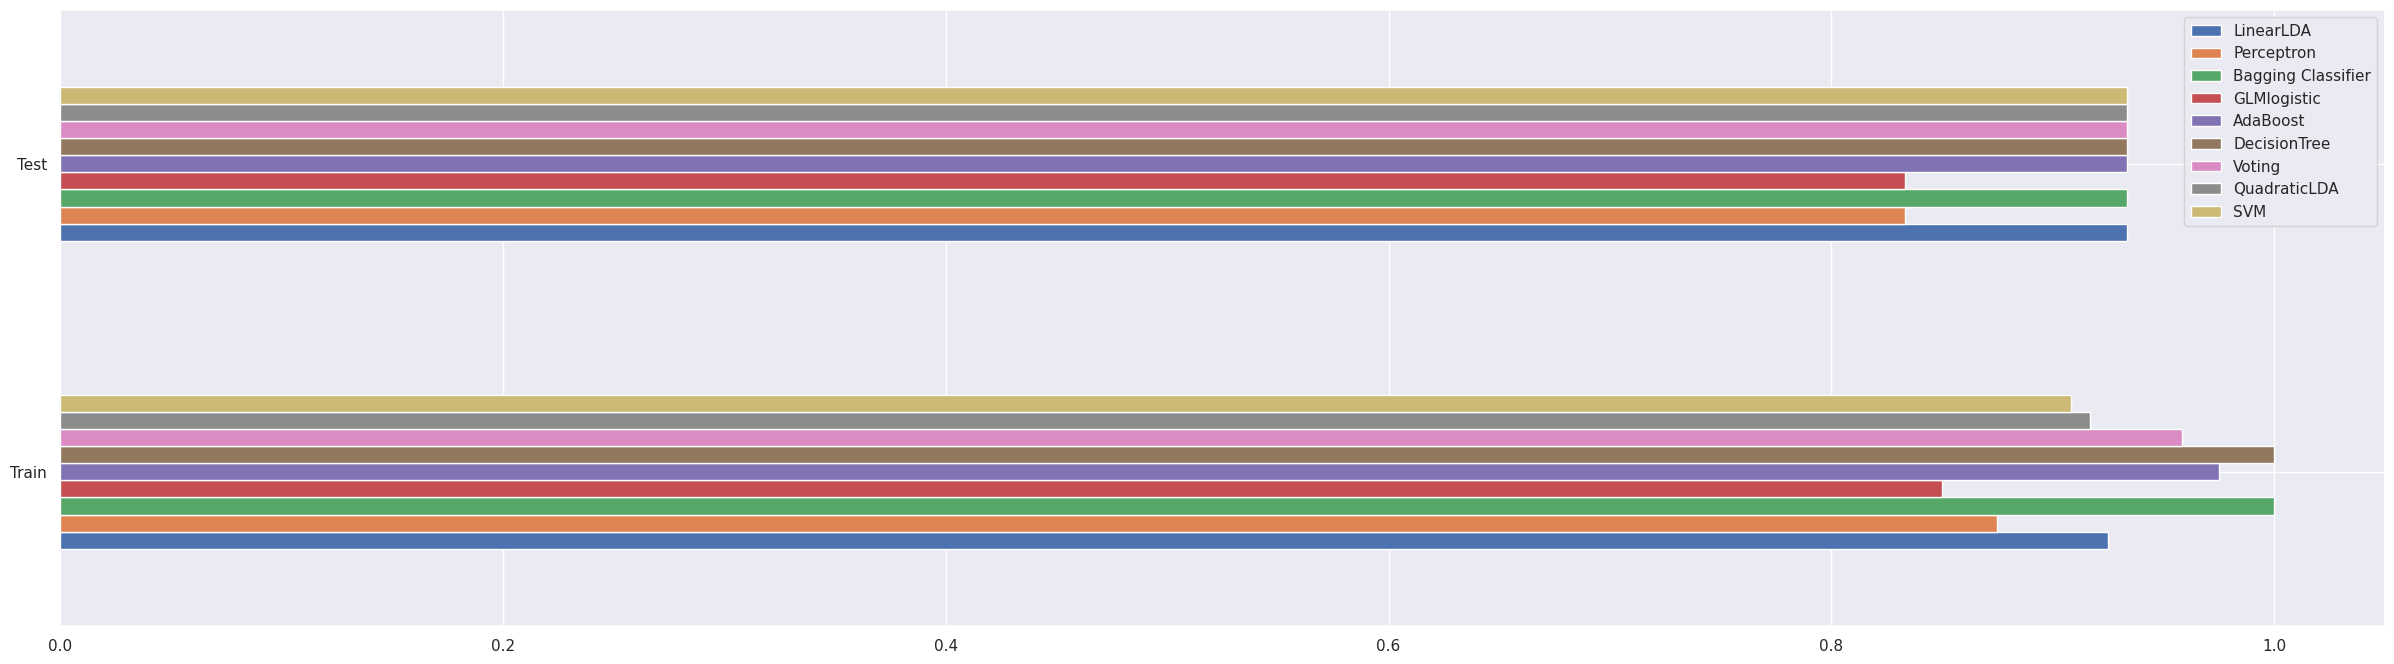

In [ ]:
scorespca_df = pd.DataFrame(scorespca)

scorespca_df.plot(kind='barh', figsize=(30, 8))

plt.savefig("comparing_classification_pca.pdf", format="pdf", bbox_inches="tight")
plt.show()



## Exercice à rendre

On veut maintenant utiliser le dataset sklearn.datasets.load_breast_cancer.

Pour ce nouveau dataset utilisez les deux tiers des données pour l'apprentissage.

1) Pourquoi souhaitons-nous apprendre un modèle de classification sur ce dataset ?

2) En vous inspirant de l'ensemble des méthodes vues sur l'apprentissage supervisée, proposez des classificateurs linéaire ou non linéaire (utilisez les deux tiers des données pour l'apprentissage). Justifiez votre approche et vos éventuels choix de paramètres. Calculez l'erreur empirique et l'erreur en généralisation des modèles appris.

3) Sur la base du meilleur modèle entraité à la question précédente, calculez la moyenne (resp. l'écart-type) de l'erreur empirique et l'erreur en généralisation sur 1000 échantillons.